1. Przetwarzanie wstępne i balansowanie zbioru danych
W pierwotnym zbiorze danych zidentyfikowano znaczny brak równowagi klasowej (85% przypadków patologicznych). Aby zapobiec biasowi modelu, zastosowano technikę Sliding Window (przesuwnego okna) o długości 2.0s z różnym krokiem (stride):

Dla klasy Normal: krok 0.5s (z zakładką), co pozwoliło na multiplikację rzadszych próbek.

Dla klasy Pathology: krok 2.0s (brak zakładki).

Efekt: Zwiększono liczebność próbek serca (HS) do 530 oraz płuc (LS) do 485, uzyskując niemal idealny balans klasowy.

In [ ]:
import os
import librosa
import soundfile as sf
import pandas as pd

def fix_imbalance_with_windows(csv_path, input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    df = pd.read_csv(csv_path)
    
    if 'Heart Sound ID' in df.columns:
        name_col = 'Heart Sound ID'
        label_col = 'Heart Sound Type'
    elif 'Lung Sound ID' in df.columns:
        name_col = 'Lung Sound ID'
        label_col = 'Lung Sound Type'
    else:
        print(f"BŁĄD: Nie znane kolumny w {csv_path}")
        return

    new_segments = []
    win_sec = 2.0  

    print(f"Przetwarzam {len(df)} nagrań z {csv_path}...")

    for _, row in df.iterrows():
        raw_id = str(row[name_col])
        fname = raw_id if raw_id.endswith('.wav') else raw_id + '.wav'
        path = os.path.join(input_dir, fname)
        
        if not os.path.exists(path):
            continue

        try:
            y, sr = librosa.load(path, sr=None)
        except Exception as e:
            continue

        win_len = int(win_sec * sr)
        
        # LOGIKA BALANSU
        label_val = str(row[label_col])
        is_normal = 'normal' in label_val.lower()
        
        #  0.5s dla zdrowych (dużo danych), 2s dla patologii (mało danych)
        step = int(0.5 * sr) if is_normal else win_len

        count = 0
        for start in range(0, len(y) - win_len + 1, step):
            segment = y[start : start + win_len]
            seg_name = f"{raw_id.replace('.wav', '')}_seg_{count}.wav"
            sf.write(os.path.join(output_dir, seg_name), segment, sr)
            
            new_segments.append({'filename': seg_name, 'label': 0 if is_normal else 1})
            count += 1

    new_df = pd.DataFrame(new_segments)
    output_csv = csv_path.replace(".csv", "_segmented.csv")
    new_df.to_csv(output_csv, index=False)
    
    print(f"Sukces! Stworzono {len(new_df)} fragmentów.")
    print(f"Podział klas (0=Normal, 1=Pathology):")
    print(new_df['label'].value_counts(normalize=True))
    print("-" * 30)

if __name__ == "__main__":
    fix_imbalance_with_windows('csv_files/HS.csv', 'Sound/HS', 'Sound/HS_segmented')
    fix_imbalance_with_windows('csv_files/LS.csv', 'Sound/LS', 'Sound/LS_segmented')

2. Klasyfikacja z wykorzystaniem Drzewa Decyzyjnego
Jako model bazowy (baseline) wybrano Drzewo Decyzyjne (Decision Tree) ze względu na jego wysoką interpretowalność. Cechy wejściowe stanowią współczynniki MFCC (Mel-frequency cepstral coefficients), które najlepiej oddają charakterystykę sygnałów medycznych.

Ekstrakcja cech z Sound/HS_segmented...

--- WYNIKI DLA SERCA (Drzewo Decyzyjne) ---
              precision    recall  f1-score   support

           0       0.94      0.93      0.94        55
           1       0.92      0.94      0.93        51

    accuracy                           0.93       106
   macro avg       0.93      0.93      0.93       106
weighted avg       0.93      0.93      0.93       106



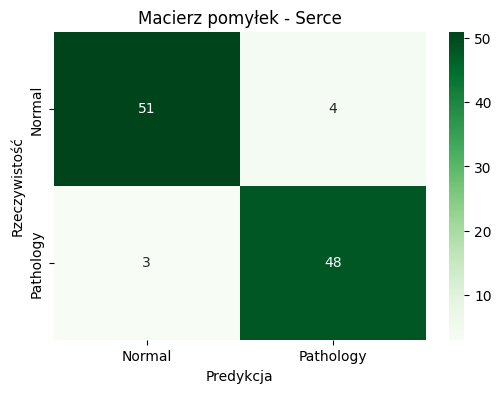

Wykresy zapisane jako pliki .png
Ekstrakcja cech z Sound/LS_segmented...

--- WYNIKI DLA PŁUC (Drzewo Decyzyjne) ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        71
           1       0.85      0.65      0.74        26

    accuracy                           0.88        97
   macro avg       0.87      0.81      0.83        97
weighted avg       0.87      0.88      0.87        97



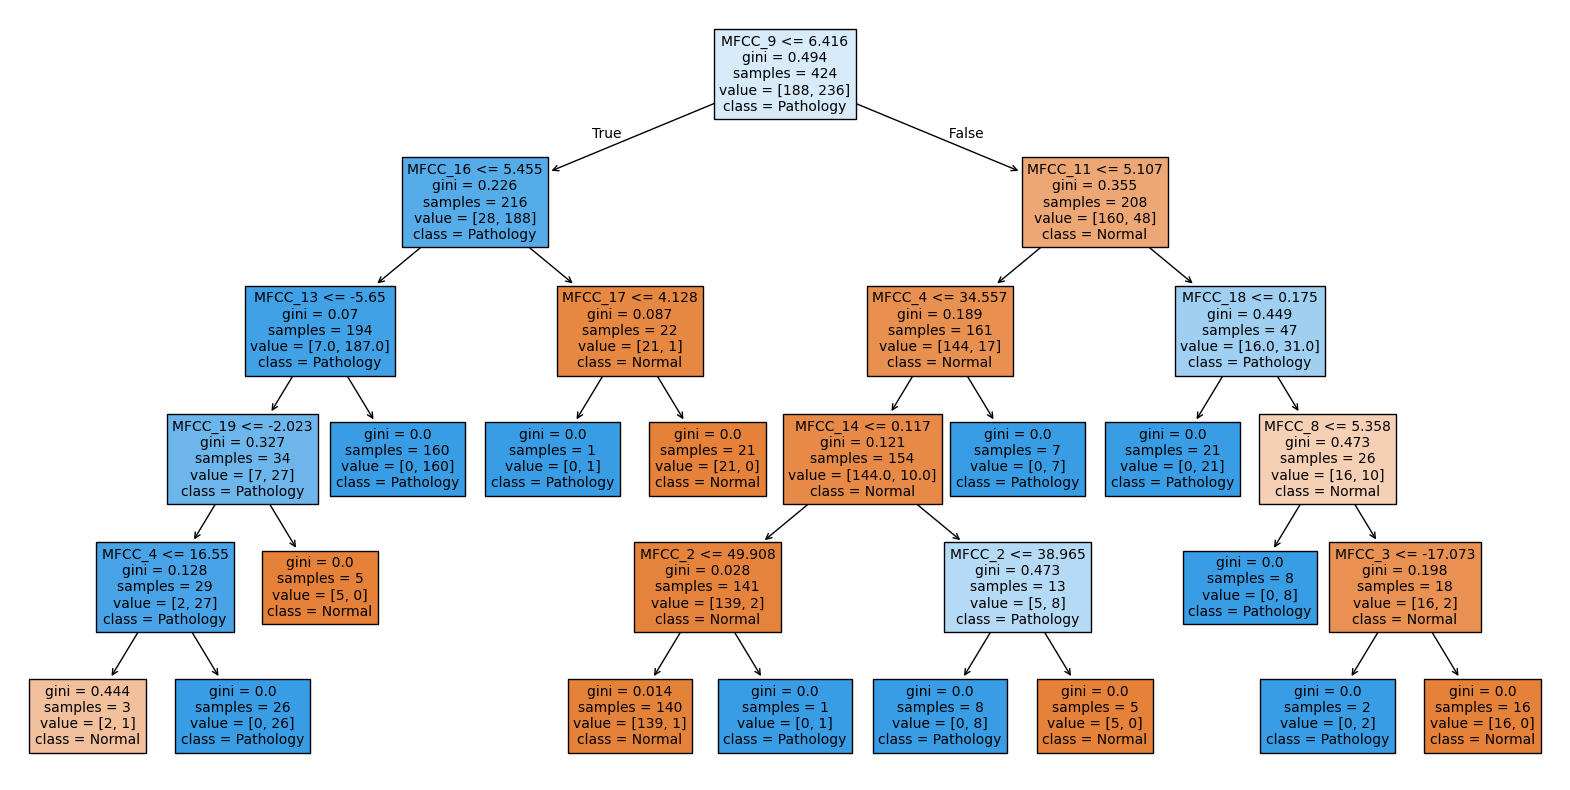

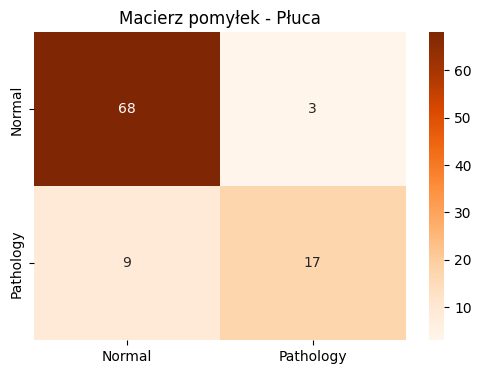

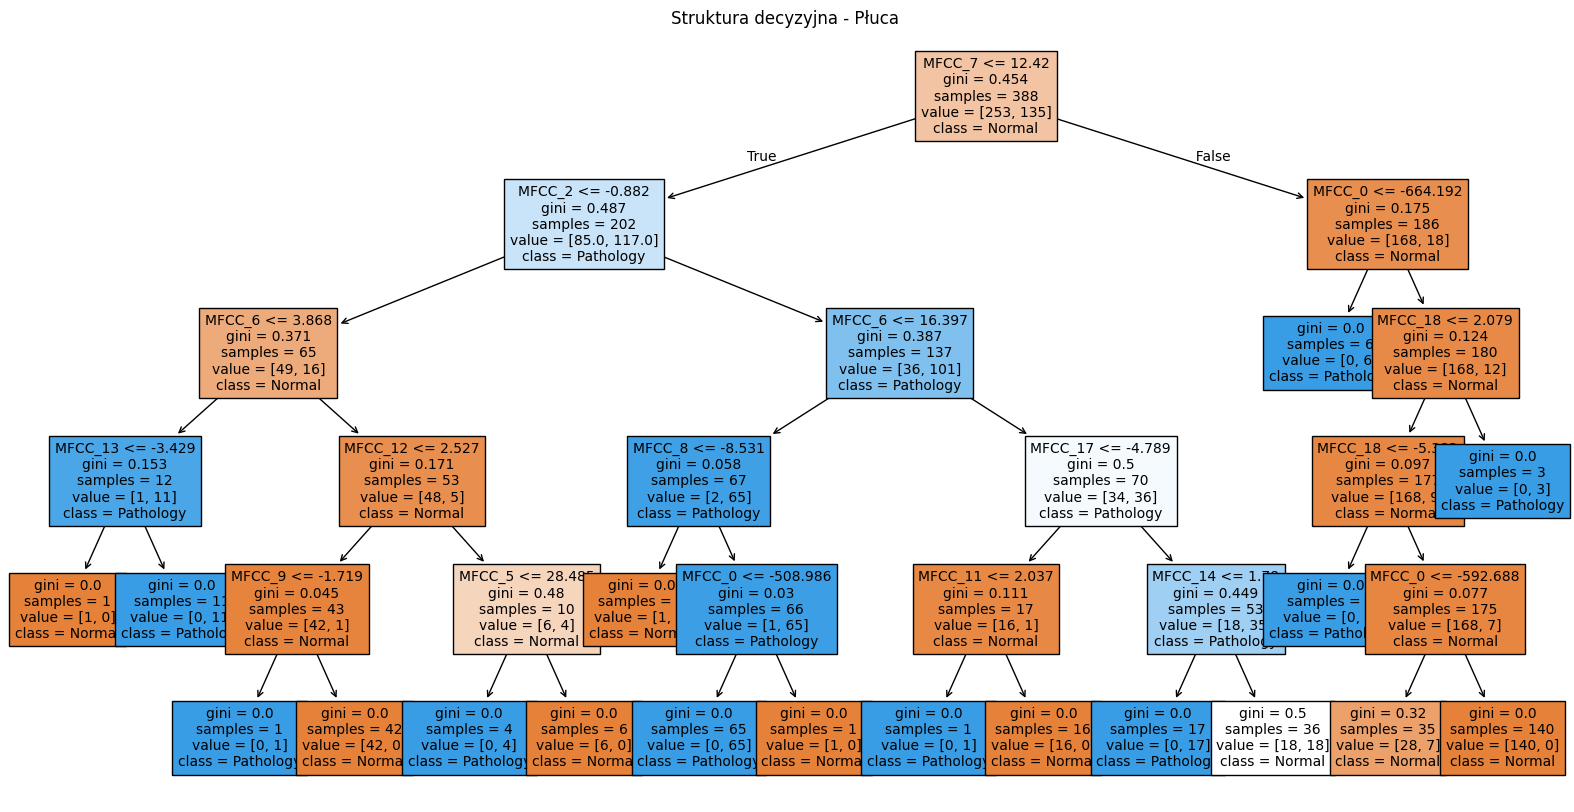

In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

def extract_features(folder, csv_file):
    df = pd.read_csv(csv_file)
    features_list = []
    labels = []
    
    print(f"Ekstrakcja cech z {folder}...")
    for _, row in df.iterrows():
        file_path = os.path.join(folder, row['filename'])
        try:
            y, sr = librosa.load(file_path, sr=None)

            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            mfccs_scaled = np.mean(mfccs.T, axis=0)
            features_list.append(mfccs_scaled)
            labels.append(row['label'])
        except:
            continue
            
    return np.array(features_list), np.array(labels)

# --- PROCES DLA SERCA (HS) ---
X_hs, y_hs = extract_features('Sound/HS_segmented', 'csv_files/HS_segmented.csv')

# Podział na trening i test
X_train, X_test, y_train, y_test = train_test_split(X_hs, y_hs, test_size=0.2, random_state=42)

# Tworzenie i trenowanie drzewa
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Wyniki
y_pred = clf.predict(X_test)
print("\n--- WYNIKI DLA SERCA (Drzewo Decyzyjne) ---")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Pathology'], yticklabels=['Normal', 'Pathology'])
plt.title('Macierz pomyłek - Serce')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.savefig('confusion_matrix_HS.png')
plt.show()

plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=[f'MFCC_{i}' for i in range(20)], class_names=['Normal', 'Pathology'], fontsize=10)
plt.savefig('decision_tree_viz.png')
print("Wykresy zapisane jako pliki .png")

# --- PROCES DLA PŁUC (LS) ---
X_ls, y_ls = extract_features('Sound/LS_segmented', 'csv_files/LS_segmented.csv')

# Podział na trening i test
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(X_ls, y_ls, test_size=0.2, random_state=42)

# Trenowanie modelu dla płuc
clf_ls = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_ls.fit(X_train_ls, y_train_ls)

# Wyniki dla płuc
y_pred_ls = clf_ls.predict(X_test_ls)
print("\n--- WYNIKI DLA PŁUC (Drzewo Decyzyjne) ---")
print(classification_report(y_test_ls, y_pred_ls))

# Macierz pomyłek dla płuc
plt.figure(figsize=(6,4))
cm_ls = confusion_matrix(y_test_ls, y_pred_ls)
sns.heatmap(cm_ls, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Pathology'], yticklabels=['Normal', 'Pathology'])
plt.title('Macierz pomyłek - Płuca')
plt.savefig('confusion_matrix_LS.png')
plt.show()

# Wizualizacja drzewa dla PŁUC (LS)
plt.figure(figsize=(20,10))
plot_tree(clf_ls, filled=True, 
          feature_names=[f'MFCC_{i}' for i in range(20)], 
          class_names=['Normal', 'Pathology'], 
          fontsize=10)
          
plt.title('Struktura decyzyjna - Płuca')
plt.savefig('decision_tree_LS_viz.png') 
plt.show()
